# 02 — Modélisation : scoring viral (Rendu 2)

Baselines → LightGBM → optimisation → interprétabilité (SHAP), en réutilisant `src/scoring/`.

Pré-requis : `python -m src.features.run_features` (dataset).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath('..'))
%matplotlib inline
import pandas as pd
from IPython.display import Image, display

from src.scoring import dataset, models
from src.scoring.metrics import evaluate

## 1. Chargement & split (anti-fuite)

`views_per_day`, `view_count`, `like_count`, `comment_count` sont exclus des features.

In [2]:
X, y = dataset.load_xy('../data/processed/dataset.csv')
X_tr, X_te, y_tr, y_te = dataset.split(X, y)
print('Features :', X.shape[1], '| train :', len(X_tr), '| test :', len(X_te))
list(X.columns)

Features : 30 | train : 380 | test : 96


['title_len_chars',
 'title_word_count',
 'title_has_number',
 'title_has_question',
 'title_has_emoji',
 'title_upper_ratio',
 'title_exclam',
 'duration_seconds',
 'is_short',
 'tag_count',
 'publish_dow',
 'publish_hour',
 'cat_QUIZ_BASKET',
 'cat_QUIZ_DATAWORLD',
 'cat_QUIZ_FOOT',
 'cat_QUIZ_GLOBAL',
 'cat_QUIZ_KPOP',
 'cat_QUIZ_OTAKU',
 'cat_QUIZ_RELIGION',
 'fam_DEVINE',
 'fam_REBUS_EMOJIS',
 'fam_TROUVER_INTRUS',
 'fam_TU_PREFERES',
 'fam_VRAI_FAUX',
 'famgrp_Choix',
 'famgrp_Devine le Mot',
 'famgrp_Personnalité',
 'famgrp_Visuel',
 'lang_EN',
 'lang_FR']

## 2. Baselines + LightGBM

In [3]:
results = {}
contenders = {**models.make_baselines(), 'lgbm': models.make_lgbm()}
for name, model in contenders.items():
    model.fit(X_tr, y_tr)
    results[name] = evaluate(y_te, model.predict(X_te))
pd.DataFrame(results).T

/home/nalf/projet/ia_soutenance/src/scoring/metrics.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, _ = spearmanr(y_true, y_pred)


,spearman,mae,rmse
dummy_mean,0.0000,0.8662,1.0248
linear,0.3609,0.7978,0.9514
lgbm,0.4758,0.7374,0.9260


## 3. Optimisation (GridSearchCV, scorer = Spearman)

In [4]:
gs = models.grid_search(X_tr, y_tr)
results['lgbm_tuned'] = evaluate(y_te, gs.predict(X_te))
print('Meilleurs params :', gs.best_params_)
pd.DataFrame(results).T.sort_values('spearman', ascending=False)

Meilleurs params : {'learning_rate': 0.03, 'min_child_samples': 20, 'n_estimators': 200, 'num_leaves': 7}


,spearman,mae,rmse
lgbm,0.4758,0.7374,0.9260
lgbm_tuned,0.4277,0.7647,0.9320
linear,0.3609,0.7978,0.9514
dummy_mean,0.0000,0.8662,1.0248


## 4. Interprétabilité (SHAP)

,feature,mean_abs_shap
0,duration_seconds,0.354938
1,title_upper_ratio,0.135263
2,title_len_chars,0.119904
3,publish_hour,0.109414
4,tag_count,0.105085
5,title_exclam,0.077093
6,publish_dow,0.056414
7,title_word_count,0.052631
8,title_has_number,0.039769
9,cat_QUIZ_RELIGION,0.037055


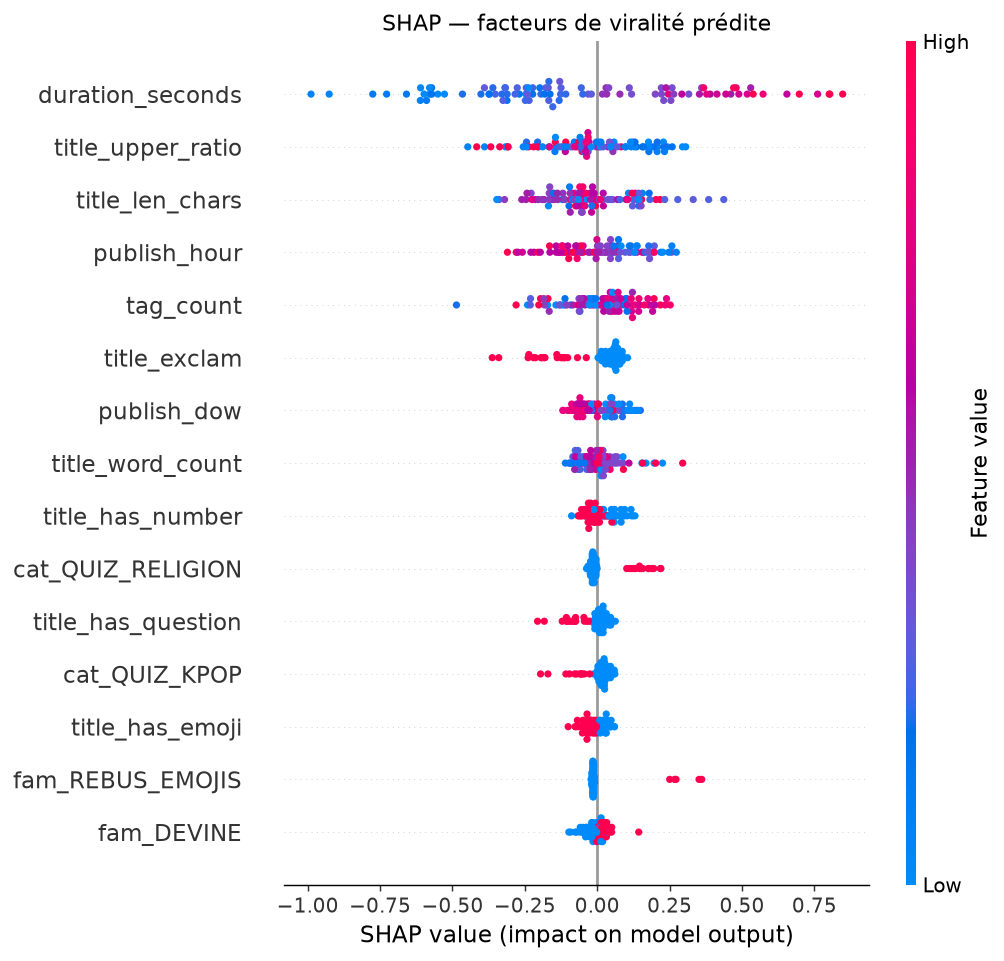

In [5]:
from src.scoring.interpret import explain
best = contenders['lgbm']   # meilleur sur le test dans notre run
importance = explain(best, X_te)
display(importance.head(10))
display(Image('../reports/figures/07_shap_summary.png'))

## 5. Conclusions

- LightGBM **bat nettement les baselines** (Spearman ~0,48 vs ~0,36 vs 0).
- Le GridSearch n'améliore pas sur ce petit volume (variance).
- **`duration_seconds`** domine l'importance SHAP (à surveiller : possible confondant).
- H2 (Spearman > 0,5) **pas encore atteinte** → pistes : features tendances/mots-clés, plus de données, embeddings de titres.